In [6]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [7]:
data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'all_cases_data.pkl')

# Read pickle file
with open(data_file, 'rb') as f:
    data = pickle.load(f)


In [10]:
DEL_LIM_ARR = data['DEL_LIM_ARR']
VAR = data['VAR']
VAR_ARR = data['VAR_ARR']
ARM_MONITOR = data['ARM_MONITOR']
NUM_ARM_PICKS_MONITOR = data['NUM_ARM_PICKS_MONITOR']

DP_MONITOR = data['DP_MONITOR']
IP_MONITOR = data['IP_MONITOR']
REWARD_MONITOR = data['REWARD_MONITOR']
ARM_TRACKER = data['ARM_TRACKER']
OPTIMAL_CHOICE_MONITOR = data['OPTIMAL_CHOICE_MONITOR']
ACTUAL_CHOICE_MONITOR = data['ACTUAL_CHOICE_MONITOR']
PROB_OPTIMAL_MONITOR = data['PROB_OPTIMAL_MONITOR']
MEAN_PROB_MONITOR = data['MEAN_PROB_MONITOR']

In [11]:

Mean_Probs_PD = [MEAN_PROB_MONITOR[VAR['PD']][del_lim] for del_lim in DEL_LIM_ARR]
Mean_Probs_std_DBS = [MEAN_PROB_MONITOR[VAR['std_DBS']][del_lim] for del_lim in DEL_LIM_ARR]
Mean_Probs_sector_DBS = [MEAN_PROB_MONITOR[VAR['sector_DBS']][del_lim] for del_lim in DEL_LIM_ARR]

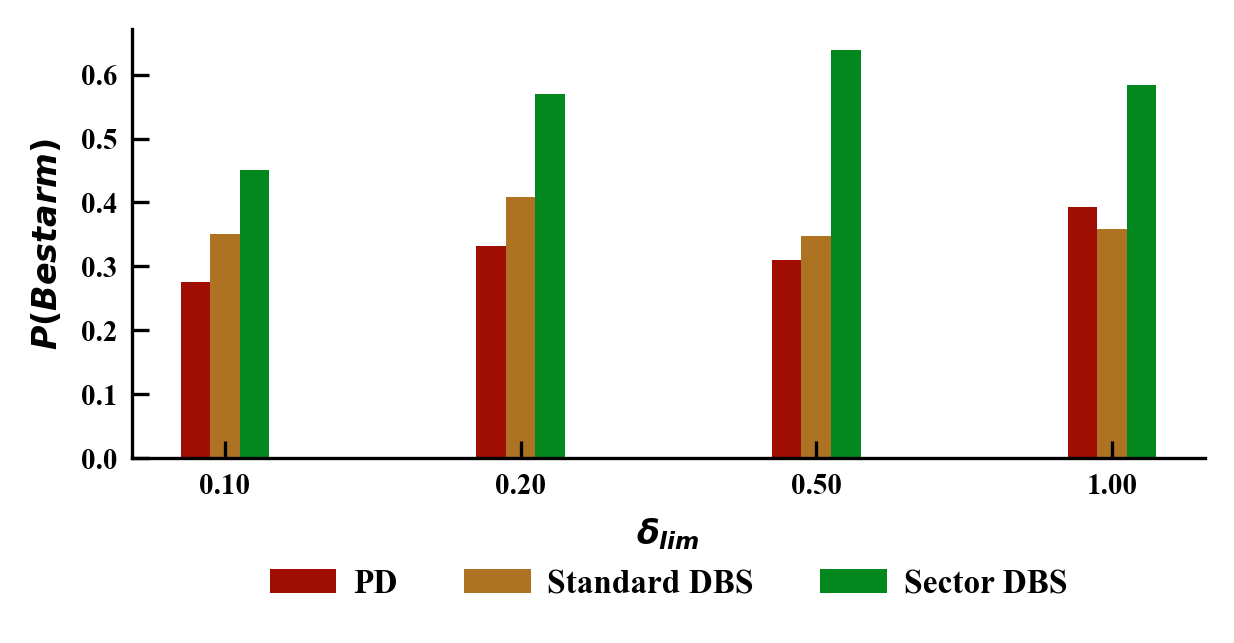

In [29]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}



plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Mean_Probs_PD, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Mean_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend(loc = 'lower center', bbox_to_anchor=(0.5,-0.4), ncol = 3)
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.show()

In [46]:
# Reading normal data
data_file_normal = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'normal_data.pkl')

# Read pickle file
with open(data_file_normal, 'rb') as f:
    normal_data = pickle.load(f)


In [61]:
EPOCH_NUM = 1
arm_chosen_monitor_normal = normal_data['arm_chosen_monitor']
reward_monitor_normal = normal_data['reward_monitor'] # recieved rew
dp_monitor_normal = normal_data['dp_monitor']
ip_monitor_normal = normal_data['ip_monitor']
arm_tracker_full_normal = normal_data['arm_tracker_full']
prob_normal = normal_data['prob']
mean_prob_normal = normal_data['mean_prob']
trials_normal = arm_chosen_monitor_normal.shape[1]
epochs_normal = arm_chosen_monitor_normal.shape[0]
num_arms = 4
arm_means_normal = arm_tracker_full_normal[EPOCH_NUM]
arm_rew_normal = np.zeros((num_arms, len(arm_means_normal)))
for i in range(len(arm_means_normal)):
    arms = arm_means_normal[i]
    rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
    arm_rew_normal[:,i] = rews

Text(0, 0.5, '$P(Best Arm)$')

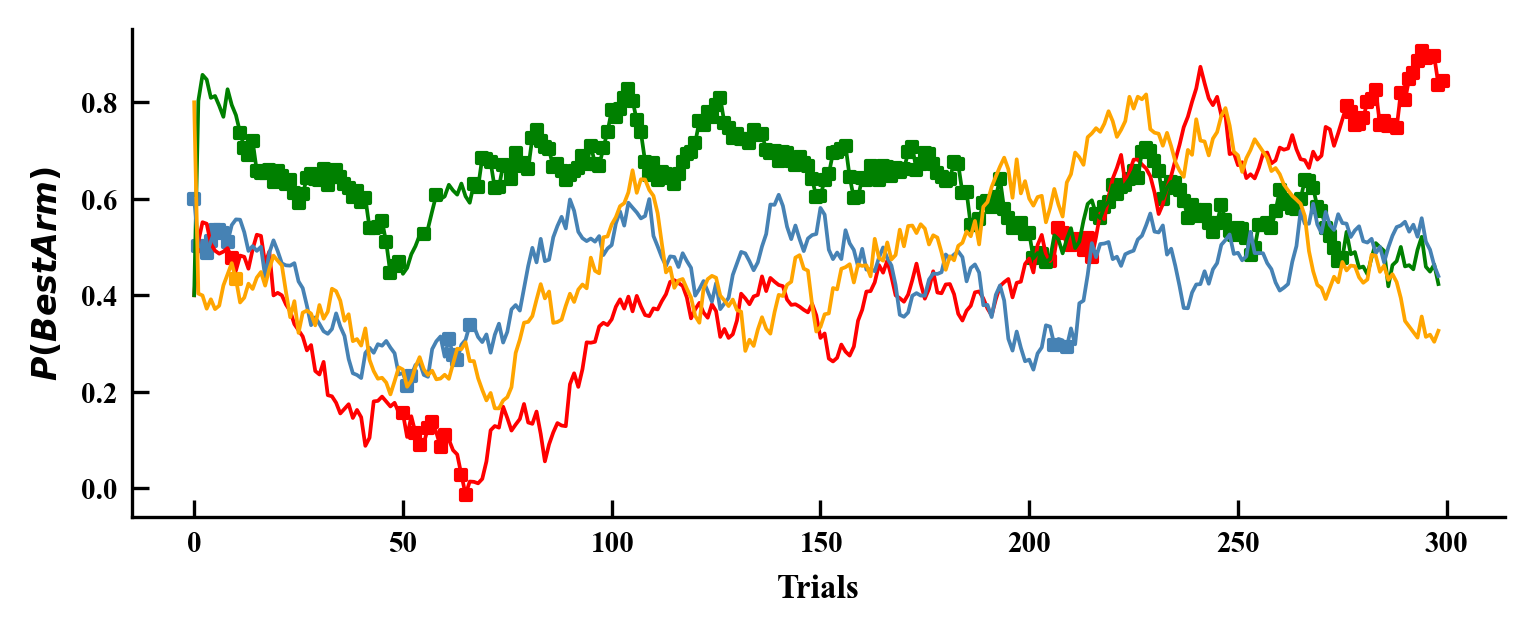

In [62]:
color_map = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}

MODIFIED_REW_ARRAY = np.zeros((num_arms,trials_normal))
for i in range(trials_normal):
    arm = int(arm_chosen_monitor_normal[EPOCH_NUM][i].detach().numpy())
    MODIFIED_REW_ARRAY[arm,i] = arm_rew_normal[arm,i]

plt.figure(figsize = (5,2))    
for i in range(num_arms):
    plt.plot(arm_rew_normal[i][0:-2], color = color_map[i], label = i, linewidth = 0.9)

    non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
    time = np.arange(trials_normal)
    filtered_time = time[non_zero_indices]
    filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
    plt.scatter(filtered_time,filtered_rewards, color = color_map[i], marker = 's', s = 5)
plt.xlabel('Trials')
plt.ylabel('$P(Best Arm)$')
# plt.title('Reward of the arm and choices of arm picking')